In [1]:
# ───────────────────────────────────────────────────────────────
# Cell 1 – Imports & switches
# ───────────────────────────────────────────────────────────────
import dadi, numpy as np, matplotlib.pyplot as plt, demes, demesdraw, pysam, pathlib, random, json, datetime

dadi.cuda_enabled(True)          # flip to False if you didn’t compile the CUDA extension


pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.creating CUBLAS context to get version number

True

In [16]:
# ───────────────────────────────────────────────────────────────
# Cell 2 – Paths & constants (edit as needed)
# ───────────────────────────────────────────────────────────────
#vcf_file   = pathlib.Path("/users/a/d/adaigle/ghist_2025/bgsgrowth/B_above75_nonsynfiltered_GHIST_2025_growth.testing.vcf")
#vcf_file   = pathlib.Path("/proj/johrilab/projects/ghist_2025/intermediate_files/austins_bmap/B.95_GHIST_2025_growth.testing.filter.vcf")
#vcf_file   = pathlib.Path("/proj/johrilab/projects/ghist_2025/intermediate_files/austins_bmap/B.95_GHIST_2025_growth.testing.filter.vcf")
vcf_file   = pathlib.Path("/proj/johrilab/projects/ghist_2025/intermediate_files/austins_bmap/B.95_GHIST_2025_growth.final.filtered.vcf")

popfile    = vcf_file.with_suffix(".popfile.txt")   # auto-create if missing
μ          = 3.36e-8                                 # per-base per-generation mut rate
L_callable = 44331000                            # bp
generation_time = 1.0                               # years
random.seed(42)


In [17]:
print(vcf_file)

/proj/johrilab/projects/ghist_2025/intermediate_files/austins_bmap/B.95_GHIST_2025_growth.final.filtered.vcf


In [18]:
# ───────────────────────────────────────────────────────────────
# Cell 3 – Auto-generate a one-population popfile (only once)
# ───────────────────────────────────────────────────────────────
if not popfile.exists():
    samples = pysam.VariantFile(str(vcf_file)).header.samples
    with popfile.open("w") as fh:
        for s in samples:
            fh.write(f"{s}\tpop1\n")
    print(f"Popfile with {len(samples)} samples written → {popfile}")


Popfile with 32 samples written → /proj/johrilab/projects/ghist_2025/intermediate_files/austins_bmap/B.95_GHIST_2025_growth.final.filtered.popfile.txt


In [19]:
# 1. How many chromosomes can we keep?
samples   = list(pysam.VariantFile(str(vcf_file)).header.samples)
n_chr_tot = len(samples) * 2           # diploid → 2 chromosomes/individual

# 2. Choose a projection. Start with the max and adjust later if needed.
proj = [n_chr_tot]                     # must be a *list* even for 1-D spectra

# 3. Make the data dictionary and spectrum
dd = dadi.Misc.make_data_dict_vcf(str(vcf_file), str(popfile))
fs = dadi.Spectrum.from_data_dict(
         dd, pop_ids=['pop1'],
         projections=proj,        # same projection you had
         polarized=True)          #  ← key change!

assert not fs.folded, "Spectrum still folded – check VCF ancestral tags"
print("Bins (unfolded):", fs.sample_sizes + 1)   # ns+1 bins instead of ⌊ns/2⌋+1

Bins (unfolded): [65]


In [20]:
# ───────────────────────────────────────────────────────────────
# Cell 5 – Define the demographic model and helper
# ───────────────────────────────────────────────────────────────
ns = fs.sample_sizes
demo_func   = dadi.Demographics1D.two_epoch
extrap_func = dadi.Numerics.make_extrap_log_func(demo_func)

# grid points – rule-of-thumb: sample size + {20,30,40}
pts_l = [int(ns[0]+20), int(ns[0]+30), int(ns[0]+40)]


In [21]:
# ───────────────────────────────────────────────────────────────
# Re-run 2-epoch optimisation with the same effort as 4-epoch
# ───────────────────────────────────────────────────────────────
import numpy as np

# use the same functions you defined before
demo_func_2   = dadi.Demographics1D.two_epoch
extrap_func_2 = dadi.Numerics.make_extrap_log_func(demo_func_2)

lower2 = np.array([0.01, 1e-4])      # still allow very small bottlenecks
upper2 = np.array([10.0,  5.0])      # now ν can go up to 10× expansion
base2  = np.sqrt(lower2 * upper2)

best_ll2, best_popt2 = -np.inf, None

# set global seed for reproducibility
np.random.seed(42)

for rep in range(20):               # 20 replicate starts
    p0 = dadi.Misc.perturb_params(
            base2, fold=2,
            lower_bound=lower2, upper_bound=upper2)
    popt = dadi.Inference.optimize_log(
               p0, fs, extrap_func_2, pts_l,
               lower_bound=lower2, upper_bound=upper2,
               maxiter=400,          # match 4-epoch effort
               verbose=False)
    ll   = dadi.Inference.ll_multinom(
               extrap_func_2(popt, fs.sample_sizes, pts_l), fs)
    print(f"[2-epoch rep {rep+1:02}]  ll={ll:8.2f}  ν={popt[0]:.3f}, T={popt[1]:.4f}")
    if ll > best_ll2:
        best_ll2, best_popt2 = ll, popt

print("\n=== Best 2-epoch fit after 20×400 optimisation steps ===")
print("  log-lik :", best_ll2)
print("  params  :", best_popt2)


[2-epoch rep 01]  ll=-10104.51  ν=0.434, T=0.0001
[2-epoch rep 02]  ll= -408.70  ν=2.825, T=0.0972
[2-epoch rep 03]  ll= -408.70  ν=2.825, T=0.0972
[2-epoch rep 04]  ll= -408.70  ν=2.825, T=0.0972
[2-epoch rep 05]  ll= -408.70  ν=2.826, T=0.0972
[2-epoch rep 06]  ll=-9987.97  ν=0.128, T=4.0088
[2-epoch rep 07]  ll= -408.70  ν=2.826, T=0.0972
[2-epoch rep 08]  ll= -408.70  ν=2.826, T=0.0972
[2-epoch rep 09]  ll= -408.70  ν=2.826, T=0.0972
[2-epoch rep 10]  ll= -408.70  ν=2.825, T=0.0972
[2-epoch rep 11]  ll= -408.70  ν=2.825, T=0.0972
[2-epoch rep 12]  ll= -408.70  ν=2.825, T=0.0972
[2-epoch rep 13]  ll= -408.70  ν=2.825, T=0.0972
[2-epoch rep 14]  ll= -408.70  ν=2.826, T=0.0972
[2-epoch rep 15]  ll= -408.70  ν=2.825, T=0.0972
[2-epoch rep 16]  ll= -408.70  ν=2.825, T=0.0972
[2-epoch rep 17]  ll=-6872.57  ν=4.354, T=4.9852
[2-epoch rep 18]  ll= -408.70  ν=2.825, T=0.0973
[2-epoch rep 19]  ll= -408.70  ν=2.826, T=0.0972
[2-epoch rep 20]  ll= -408.70  ν=2.825, T=0.0972

=== Best 2-epoch f

In [22]:
# ───────────────────────────────────────────────────────────────
# Add exponential‐growth model and compare AIC
# ───────────────────────────────────────────────────────────────

import numpy as np

# 1) Define the growth model
def growth(params, ns, pts):
    nu, T = params
    xx = dadi.Numerics.default_grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)
    # exponential growth from ancestral size to nu over time T
    nu_func = lambda t: np.exp(np.log(nu) * t / T)
    phi = dadi.Integration.one_pop(phi, xx, T, nu_func)
    return dadi.Spectrum.from_phi(phi, ns, (xx,))

# 2) Wrap with extrapolation
demo_func_growth  = growth
extrap_func_growth = dadi.Numerics.make_extrap_log_func(demo_func_growth)

# 3) Set bounds just like two‐epoch
lower_growth = np.array([0.01, 1e-4])      # nu, T
upper_growth = np.array([10.0,  5.0])      # up to 10× expansion, T up to 5
base_growth  = np.sqrt(lower_growth * upper_growth)

best_llg, best_poptg = -np.inf, None
np.random.seed(42)

# 4) 20 replicate starts
for rep in range(20):
    p0 = dadi.Misc.perturb_params(base_growth, fold=2,
                                  lower_bound=lower_growth,
                                  upper_bound=upper_growth)
    poptg = dadi.Inference.optimize_log(
                p0, fs, extrap_func_growth, pts_l,
                lower_bound=lower_growth, upper_bound=upper_growth,
                maxiter=400, verbose=False)
    llg = dadi.Inference.ll_multinom(
                extrap_func_growth(poptg, fs.sample_sizes, pts_l), fs)
    print(f"[growth rep {rep+1:02}] ll={llg:8.2f}  nu={poptg[0]:.3f}, T={poptg[1]:.4f}")
    if llg > best_llg:
        best_llg, best_poptg = llg, poptg

print("\n=== Best exponential‐growth fit ===")
print("  log‑lik :", best_llg)
print("  params  :", best_poptg)


[growth rep 01] ll= -422.91  nu=3.461, T=0.1514
[growth rep 02] ll= -422.91  nu=3.460, T=0.1514
[growth rep 03] ll= -422.91  nu=3.460, T=0.1514
[growth rep 04] ll= -422.91  nu=3.460, T=0.1514
[growth rep 05] ll= -422.91  nu=3.460, T=0.1514
[growth rep 06] ll=-46672.64  nu=0.210, T=0.0544
[growth rep 07] ll= -422.91  nu=3.460, T=0.1514
[growth rep 08] ll= -422.91  nu=3.460, T=0.1515
[growth rep 09] ll= -422.91  nu=3.460, T=0.1514
[growth rep 10] ll= -422.91  nu=3.460, T=0.1514
[growth rep 11] ll= -422.91  nu=3.462, T=0.1513
[growth rep 12] ll= -422.91  nu=3.461, T=0.1513
[growth rep 13] ll= -422.91  nu=3.460, T=0.1514
[growth rep 14] ll= -422.91  nu=3.460, T=0.1514
[growth rep 15] ll= -422.91  nu=3.460, T=0.1514


KeyboardInterrupt: 

In [46]:
# 5) AIC comparison
# AIC = 2*k – 2*LL, where k = number of free parameters
k2   = len(best_popt2)    # two‑epoch has 2 params
aic2 = 2*k2   - 2*best_ll2
kg   = len(best_poptg)    # growth has 2 params
aicg = 2*kg   - 2*best_llg

print("\n=== AIC comparison ===")
print(f"Two‑epoch: AIC = {aic2:.2f}")
print(f"Growth   : AIC = {aicg:.2f}")

if aicg < aic2:
    print("=> Exponential‑growth model is preferred (lower AIC).")
else:
    print("=> Two‑epoch (instantaneous change) is preferred.")


=== AIC comparison ===
Two‑epoch: AIC = 777.96
Growth   : AIC = 773.22
=> Exponential‑growth model is preferred (lower AIC).


Ignoring specified arguments in this call because figure with num: 1 already exists

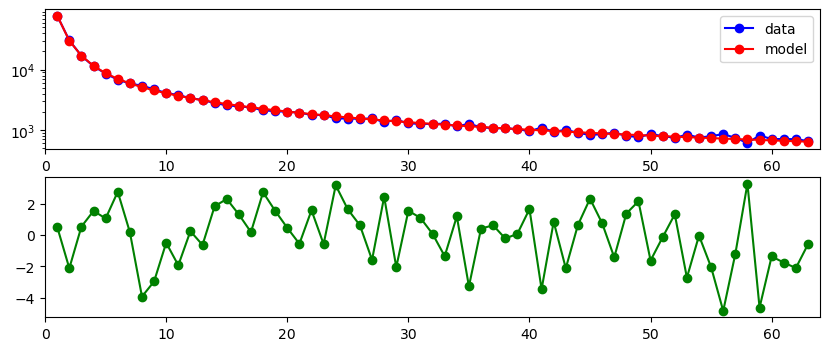

In [23]:
# ───────────────────────────────────────────────────────────────
# Cell 7 – Goodness-of-fit plot (observed vs model)
# ───────────────────────────────────────────────────────────────
model_fs = extrap_func(best_popt2, fs.sample_sizes, pts_l)
fig = plt.figure(figsize=(10,4))
# 1-D version: no resid_range, no vmin
dadi.Plotting.plot_1d_comp_multinom(model_fs, fs,
                                    fig_num=fig.number)
plt.show()


θ (MLE)                      : 40,514.65
Ancestral size   (N_a)       : 9,285
Bottleneck size  (N_bottle)  : 26,243
Time of change   (generations): 1,805
Time of change   (years)      : 1,805


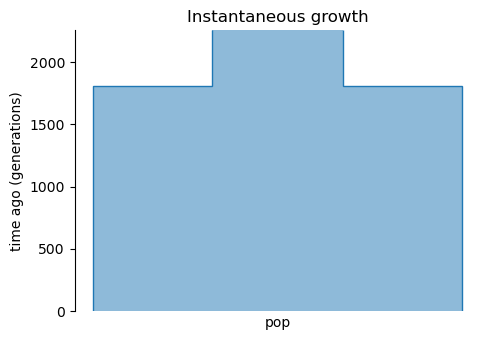

In [24]:
# ───────────────────────────────────────────────────────────────
# Cell 7b – Convert popt to Ne & time, then draw with demes
# ───────────────────────────────────────────────────────────────
import dadi, demes, demesdraw, matplotlib.pyplot as plt
mu          = μ                             # per-base per-generation mut rate
L_callable = 32464419
# ---- 1.  Estimate θ from the fitted model and data -------------
theta = dadi.Inference.optimal_sfs_scaling(model_fs, fs)

# Ancestral Ne
N_ancestral = theta / (4 * mu * L_callable)

# Bottleneck parameters (ν = Nbottleneck / Nancestral ,  T in 2N_ancestral units)
nu, T = best_popt2
N_bottleneck = nu * N_ancestral
T_gen        = T * 2 * N_ancestral          # generations ago
T_years      = T_gen * generation_time

print(f"θ (MLE)                      : {theta:,.2f}")
print(f"Ancestral size   (N_a)       : {N_ancestral:,.0f}")
print(f"Bottleneck size  (N_bottle)  : {N_bottleneck:,.0f}")
print(f"Time of change   (generations): {T_gen:,.0f}")
print(f"Time of change   (years)      : {T_years:,.0f}")

# ---- 3.  Write the model as Demes YAML -------------------------
yaml_model = f"""
description: Single-population instantaneous bottleneck
time_units: generations
demes:
  - name: pop
    epochs:
      - end_time: {T_gen:.2f}
        start_size: {N_ancestral:.2f}
      - end_time: 0
        start_size: {N_bottleneck:.2f}
"""

graph = demes.loads(yaml_model)        # Load YAML → demes.Graph

# ---- 4.  Plot ---------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 3.5))
demesdraw.tubes(graph, ax=ax)
ax.set_title("Instantaneous growth")
plt.tight_layout()
plt.show()


Instantaneous‑change model:
  ν (relative size)               : 2.082
  Final size (N_Final)      : 16,283
  Time of change (generations ago): 1,824
Exponential‑growth model:
  ν (fold change)                 : 2.369
  Final size (N_final)            : 18,526
  Growth onset (generations ago)  : 3,057


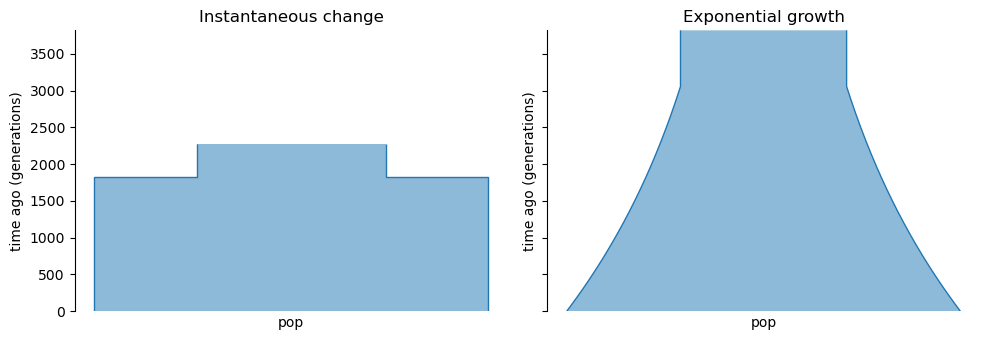

In [49]:
# Cell 7b – Convert both sets of parameters to Ne & time, then draw side‑by‑side
import dadi, demes, demesdraw, matplotlib.pyplot as plt

# reuse these from above
mu              = μ               # per-base per-generation
generation_time = generation_time # years per generation
L_callable      = L_callable      # callable length
model_fs        = model_fs        # two‑epoch spectrum you already generated

# ---- 1.  Estimate θ and ancestral Ne (same for both models) -------------
theta       = dadi.Inference.optimal_sfs_scaling(model_fs, fs)
N_ancestral = theta / (4 * mu * L_callable)

# ---- 2.  Instantaneous model → interpretable units -----------------------
nu_i      , T_i       = best_popt2
N_bottle   = nu_i * N_ancestral
T_gen_i    = T_i * 2 * N_ancestral
T_years_i  = T_gen_i * generation_time

print("Instantaneous‑change model:")
print(f"  ν (relative size)               : {nu_i:.3f}")
print(f"  Final size (N_Final)      : {N_bottle:,.0f}")
print(f"  Time of change (generations ago): {T_gen_i:,.0f}")

# ---- 3.  Exponential model → interpretable units --------------------------
nu_g      , T_g       = best_poptg
N_final    = nu_g * N_ancestral
T_gen_g    = T_g * 2 * N_ancestral
T_years_g  = T_gen_g * generation_time

print("Exponential‑growth model:")
print(f"  ν (fold change)                 : {nu_g:.3f}")
print(f"  Final size (N_final)            : {N_final:,.0f}")
print(f"  Growth onset (generations ago)  : {T_gen_g:,.0f}")

# ---- 4.  Build Demes YAML for both ----------------------------------------
yaml_inst = f"""
description: Instantaneous size change
time_units: generations
demes:
  - name: pop
    epochs:
      - end_time: {T_gen_i:.2f}
        start_size: {N_ancestral:.2f}
      - end_time: 0
        start_size: {N_bottle:.2f}
"""

yaml_exp = f"""
description: Exponential growth
time_units: generations
demes:
  - name: pop
    epochs:
      # before growth: constant ancestral size
      - end_time: {T_gen_g:.2f}
        start_size: {N_ancestral:.2f}
        end_size:   {N_ancestral:.2f}
      # growth epoch
      - end_time: 0
        start_size: {N_ancestral:.2f}
        end_size:   {N_final:.2f}
"""

graph_inst = demes.loads(yaml_inst)
graph_exp  = demes.loads(yaml_exp)

# ---- 5.  Plot side‑by‑side -----------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

demesdraw.tubes(graph_inst, ax=ax1)
ax1.set_title("Instantaneous change")

demesdraw.tubes(graph_exp, ax=ax2)
ax2.set_title("Exponential growth")

plt.tight_layout()
plt.show()


In [43]:
# ───────────────────────────────────────────────────────────────
# Cell 8 – Define 3‑ and 4‑epoch demographic models
# ───────────────────────────────────────────────────────────────
import dadi, numpy as np, scipy.stats as stats

# 3‑epoch: ancestral (size=1) → ν1 for T1 → ν2 for T2 → present
# params = [ν1, ν2, T1, T2]

def three_epoch(params, ns, pts):
    """One‑population, three‑epoch model.
    params = (nu1, nu2, T1, T2)
        nu1, nu2 : population sizes relative to the ancestral size (Na)
        T1, T2   : times (coalescent units, i.e. 2Na generations) of each epoch
    """
    nu1, nu2, T1, T2 = params
    xx  = dadi.Numerics.default_grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)               # ancestral size = 1
    phi = dadi.Integration.one_pop(phi, xx, T1, nu=nu1)  # ancient → middle
    phi = dadi.Integration.one_pop(phi, xx, T2, nu=nu2)  # middle → recent
    fs  = dadi.Spectrum.from_phi(phi, ns, (xx,))
    return fs

# 4‑epoch: ancestral → ν1 (T1) → ν2 (T2) → ν3 (T3) → present
# params = [ν1, ν2, ν3, T1, T2, T3]

def four_epoch(params, ns, pts):
    """One‑population, four‑epoch model.
    params = (nu1, nu2, nu3, T1, T2, T3)
    """
    nu1, nu2, nu3, T1, T2, T3 = params
    xx  = dadi.Numerics.default_grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)
    phi = dadi.Integration.one_pop(phi, xx, T1, nu=nu1)
    phi = dadi.Integration.one_pop(phi, xx, T2, nu=nu2)
    phi = dadi.Integration.one_pop(phi, xx, T3, nu=nu3)
    fs  = dadi.Spectrum.from_phi(phi, ns, (xx,))
    return fs

# Extrapolated versions for fast likelihood calculations
three_epoch_ex = dadi.Numerics.make_extrap_log_func(three_epoch)
four_epoch_ex  = dadi.Numerics.make_extrap_log_func(four_epoch)

In [44]:
# ───────────────────────────────────────────────────────────────
# Cell 9 – Fit 3‑ and 4‑epoch models (20 replicate starts each)
# ───────────────────────────────────────────────────────────────
# (Re‑use fs, pts_l, etc. from earlier cells)

rng = np.random.default_rng(42)

# ------- 3‑epoch optimisation -----------------------------------
lower3 = np.array([0.01, 0.01, 1e-4, 1e-4])   # ν1, ν2, T1, T2
upper3 = np.array([10.0, 10.0, 5.0,  5.0 ])
base3  = np.sqrt(lower3 * upper3)              # geometric mid‑point

best_ll3, best_popt3 = -np.inf, None
for rep in range(20):
    p0 = dadi.Misc.perturb_params(base3, fold=2,
                                  lower_bound=lower3,
                                  upper_bound=upper3)
    popt = dadi.Inference.optimize_log(p0, fs, three_epoch_ex, pts_l,
                                       lower_bound=lower3, upper_bound=upper3,
                                       maxiter=300, verbose=False)
    ll = dadi.Inference.ll_multinom(three_epoch_ex(popt, fs.sample_sizes, pts_l), fs)
    print(f"[3‑epoch rep {rep+1:02}]  ll={ll:9.2f}   params={np.round(popt,3)}")
    if ll > best_ll3:
        best_ll3, best_popt3 = ll, popt

# ------- 4‑epoch optimisation -----------------------------------
lower4 = np.array([0.01, 0.01, 0.01, 1e-4, 1e-4, 1e-4])   # ν1‑3, T1‑3
upper4 = np.array([10.0, 10.0, 10.0, 5.0,  5.0,  5.0 ])
base4  = np.sqrt(lower4 * upper4)

best_ll4, best_popt4 = -np.inf, None
for rep in range(20):
    p0 = dadi.Misc.perturb_params(base4, fold=2,
                                  lower_bound=lower4,
                                  upper_bound=upper4)
    popt = dadi.Inference.optimize_log(p0, fs, four_epoch_ex, pts_l,
                                       lower_bound=lower4, upper_bound=upper4,
                                       maxiter=400, verbose=False)
    ll = dadi.Inference.ll_multinom(four_epoch_ex(popt, fs.sample_sizes, pts_l), fs)
    print(f"[4‑epoch rep {rep+1:02}]  ll={ll:9.2f}   params={np.round(popt,3)}")
    if ll > best_ll4:
        best_ll4, best_popt4 = ll, popt

[3‑epoch rep 01]  ll=  -640.93   params=[9.421 1.673 0.    0.19 ]
[3‑epoch rep 02]  ll=  -362.95   params=[1.522 2.117 0.08  0.065]
[3‑epoch rep 03]  ll= -1334.21   params=[5.062 1.508 0.    0.361]
[3‑epoch rep 04]  ll=  -362.94   params=[1.548 2.12  0.081 0.062]
[3‑epoch rep 05]  ll=  -519.99   params=[9.845e+00 1.796e+00 3.000e-03 1.860e-01]
[3‑epoch rep 06]  ll= -6844.84   params=[7.003 0.625 0.022 0.028]
[3‑epoch rep 07]  ll= -5533.87   params=[1.512e+00 4.627e+00 2.000e-03 3.794e+00]
[3‑epoch rep 08]  ll=  -365.05   params=[2.950e-01 2.026e+00 1.000e-03 1.200e-01]
[3‑epoch rep 09]  ll=  -363.08   params=[1.376 2.111 0.083 0.075]
[3‑epoch rep 10]  ll= -7961.51   params=[5.031e+00 2.440e-01 1.200e-02 5.000e-03]
[3‑epoch rep 11]  ll=  -365.53   params=[9.949e+00 2.023e+00 9.000e-03 1.000e-01]
[3‑epoch rep 12]  ll=  -364.95   params=[1.656 2.029 0.    0.115]
[3‑epoch rep 13]  ll=  -364.95   params=[0.319 2.029 0.    0.115]
[3‑epoch rep 14]  ll=  -363.77   params=[1.895 2.42  0.113 0.0

In [45]:
# ───────────────────────────────────────────────────────────────
# Cell 10 – Model comparison: AIC + Likelihood‑ratio tests
# ───────────────────────────────────────────────────────────────
# (Uses best_ll from the single‑bottleneck fit defined earlier)

models = {
    "2‑epoch": {"k": len(best_popt2),   "ll": best_ll2},
    "3‑epoch": {"k": len(best_popt3), "ll": best_ll3},
    "4‑epoch": {"k": len(best_popt4), "ll": best_ll4},
}

for m in models.values():
    m["aic"] = 2*m["k"] - 2*m["ll"]

print("\nAkaike Information Criterion (lower = better)")
for name, m in models.items():
    print(f"{name:7}  k={m['k']:2d}  ll={m['ll']:9.2f}  AIC={m['aic']:9.2f}")

# Likelihood‑ratio helper

def lr_test(ll0, ll1, df):
    D = 2*(ll1 - ll0)
    p = stats.chi2.sf(D, df)
    return D, p

D_3_vs_1, p_3_vs_1 = lr_test(models["2‑epoch"]["ll"], models["3‑epoch"]["ll"],
                             models["3‑epoch"]["k"] - models["2‑epoch"]["k"])
D_4_vs_3, p_4_vs_3 = lr_test(models["3‑epoch"]["ll"], models["4‑epoch"]["ll"],
                             models["4‑epoch"]["k"] - models["3‑epoch"]["k"])

print("\nLikelihood‑ratio tests (nested models)")
print(f"3‑epoch vs 2‑epoch :  D={D_3_vs_1:.2f}  df={models['3‑epoch']['k'] - models['2‑epoch']['k']}  p={p_3_vs_1:.3g}")
print(f"4‑epoch vs 3‑epoch :  D={D_4_vs_3:.2f}  df={models['4‑epoch']['k'] - models['3‑epoch']['k']}  p={p_4_vs_3:.3g}")



Akaike Information Criterion (lower = better)
2‑epoch  k= 2  ll=  -364.95  AIC=   733.89
3‑epoch  k= 4  ll=  -362.94  AIC=   733.89
4‑epoch  k= 6  ll=  -362.49  AIC=   736.98

Likelihood‑ratio tests (nested models)
3‑epoch vs 2‑epoch :  D=4.00  df=2  p=0.135
4‑epoch vs 3‑epoch :  D=0.91  df=2  p=0.635


In [46]:
# ───────────────────────────────────────────────────────────────
# Cell 6a – Evaluate the 1-epoch (constant-size) model
# ───────────────────────────────────────────────────────────────
# dadi’s standard-neutral model (SNM) is constant size and
# formally has *zero* free parameters, but the function’s
# signature is snm(params, ns, pts) – so we still need a
# “params” slot when we call it.

def _snm_wrapper(params, ns, pts):
    # params is unused (can be [], None, whatever), but we must
    # pass it on in the correct position.
    return dadi.Demographics1D.snm(params, ns, pts)

demo_func_1   = _snm_wrapper
extrap_func_1 = dadi.Numerics.make_extrap_log_func(demo_func_1)

best_popt_1 = []        # no parameters
# Evaluate the likelihood once
model_fs_1  = extrap_func_1(best_popt_1, fs.sample_sizes, pts_l)
best_ll_1   = dadi.Inference.ll_multinom(model_fs_1, fs)

print(f"Constant-size (1-epoch) log-likelihood: {best_ll_1:.2f}")


Constant-size (1-epoch) log-likelihood: -4615.77


In [47]:
# ───────────────────────────────────────────────────────────────
# Cell 5a – Demographic functions for 3- and 4-epoch models
# ───────────────────────────────────────────────────────────────
import dadi, numpy as np

# ----------------------------------------------------------------
# 3-epoch : ν1 (oldest) → ν2 (modern), times T1 (oldest) & T2
# order: integrate **backwards** from present (ν2) to past
# ----------------------------------------------------------------
def three_epoch(params, ns, pts):
    nu1, nu2, T1, T2 = params        # oldest→newest order
    xx  = dadi.Numerics.default_grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)
    phi = dadi.Integration.one_pop(phi, xx, T=T2, nu=nu2)  # most recent
    phi = dadi.Integration.one_pop(phi, xx, T=T1, nu=nu1)  # older
    return dadi.Spectrum.from_phi(phi, ns, (xx,))

# ----------------------------------------------------------------
# 4-epoch : ν1 (oldest) → ν3 (modern), times T1, T2, T3
# ----------------------------------------------------------------
def four_epoch(params, ns, pts):
    nu1, nu2, nu3, T1, T2, T3 = params
    xx  = dadi.Numerics.default_grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)
    phi = dadi.Integration.one_pop(phi, xx, T=T3, nu=nu3)  # present-day size
    phi = dadi.Integration.one_pop(phi, xx, T=T2, nu=nu2)
    phi = dadi.Integration.one_pop(phi, xx, T=T1, nu=nu1)
    return dadi.Spectrum.from_phi(phi, ns, (xx,))

# Extrapolation wrappers
demo_func_3   = three_epoch
three_epoch_ex = dadi.Numerics.make_extrap_log_func(demo_func_3)

demo_func_4   = four_epoch
four_epoch_ex = dadi.Numerics.make_extrap_log_func(demo_func_4)


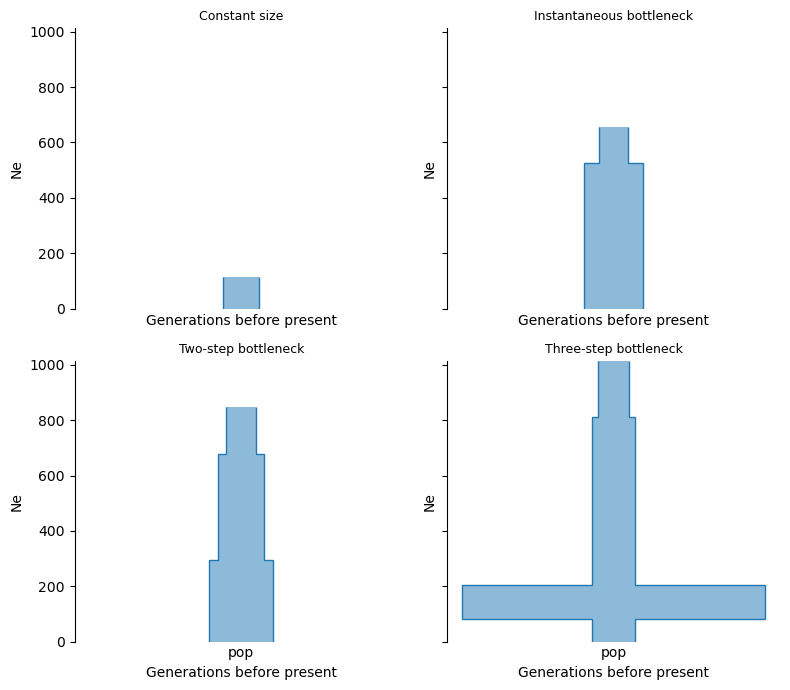

,model,k,Na,N_1,T_1 gen,T_1 years,N_2,T_2 gen,T_2 years,N_3,T_3 gen,T_3 years
0,Constant size,0,"2,808",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Instantaneous bottleneck,2,"2,296","4,660",526,526,NaN,NaN,NaN,NaN,NaN,NaN
2,Two‑step bottleneck,4,"2,368","3,665",678,678,"5,020",295,295,NaN,NaN,NaN
3,Three‑step bottleneck,6,"2,416","3,366",810,810,"23,930",206,206,"3,465",83,83


In [48]:
# ───────────────────────────────────────────────────────────────
# Cell X – Summarise & plot constant, 2-, 3-, 4-epoch fits
# ───────────────────────────────────────────────────────────────
import numpy as np, dadi, demes, demesdraw, matplotlib.pyplot as plt, pandas as pd

# 0) Gather fits present in memory
models = {
    "1-epoch": dict(extrap=extrap_func_1, popt=best_popt_1,
                    label="Constant size"),
    "2-epoch": dict(extrap=(extrap_func_2 if "extrap_func_2" in globals() else extrap_func),
                    popt=(best_popt2   if "best_popt2"   in globals() else best_popt),
                    label="Instantaneous bottleneck"),
}
if "best_popt3" in globals():
    models["3-epoch"] = dict(
        extrap=three_epoch_ex,
        popt=best_popt3,
        label="Two‑step bottleneck"
    )
if "best_popt4" in globals():
    models["4-epoch"] = dict(
        extrap=four_epoch_ex,
        popt=best_popt4,
        label="Three‑step bottleneck"
    )

# 1) Helper – dadi params → Demes graph
def build_graph(Na, nu_params, time_params, label):
    sizes = [Na] + [nu * Na for nu in nu_params]
    if len(time_params) > 0:                                      # ← fixed
        gens      = [t * 2 * Na for t in time_params]             # oldest→newest
        end_times = np.append(np.cumsum(gens[::-1])[::-1], 0)     # + present
    else:
        end_times = [0]
    yaml = ["description: " + label, "time_units: generations",
            "demes:", "  - name: pop", "    epochs:"]
    for sz, et in zip(sizes, end_times):
        yaml.append(f"      - end_time: {et:.6g}")
        yaml.append(f"        start_size: {sz:.6g}")
    return demes.loads("\n".join(yaml)), end_times[:-1]           # omit trailing 0

# 2) Loop through models: compute θ, Na, build plots & summaries
rows, graphs = [], []
μ_here = locals().get("mu", locals().get("μ"))

for key, d in models.items():
    popt = np.asarray(d["popt"]).tolist()            # ensure list
    k    = len(popt)
    nu_p = popt[: k // 2]
    t_p  = popt[k // 2:]

    fs_mod = d["extrap"](popt, fs.sample_sizes, pts_l)
    θ      = dadi.Inference.optimal_sfs_scaling(fs_mod, fs)
    Na     = θ / (4 * μ_here * L_callable)

    graph, change_times = build_graph(Na, nu_p, t_p, d["label"])
    graphs.append((d["label"], graph))

    row = {"model": d["label"], "k": k, "Na": f"{Na:,.0f}"}
    for i, ν in enumerate(nu_p, 1):
        row[f"N_{i}"] = f"{ν * Na:,.0f}"
    for i, et in enumerate(change_times, 1):
        row[f"T_{i} gen"]   = f"{et:,.0f}"
        row[f"T_{i} years"] = f"{et * generation_time:,.0f}"
    rows.append(row)

# 3) Plot demographic histories
n = len(graphs)
cols = int(np.ceil(np.sqrt(n)))
rows_fig = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows_fig, cols, figsize=(4 * cols, 3.5 * rows_fig),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, (label, g) in zip(axes, graphs):
    demesdraw.tubes(g, ax=ax)
    for txt in list(ax.texts):                   # remove “pop”
        if txt.get_text().strip().lower() == "pop":
            txt.remove()
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Generations before present")
    ax.set_ylabel("Ne")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 4) Parameter table
pd.set_option("display.max_columns", None, "display.width", 0)
display(pd.DataFrame(rows))
